EN ESTE NOTEBOOK:
- Se crea un dataset con las variables del momento del embarazo (antecedentes en el momento de la gestación, gestación, parto, complicaciones gestacionales)

- Se apuntan las variables con:

        - Más entre 20 y 35% de missings
        - Con outliers o valores raros

- Se comprueba que en ese dataset: 

        - Las pacientes y variables con más de 35% de missings están eliminadas
        - Las variables nominales y ordinales están bien diferenciadas
        - One Hot Encoding está aplicado en las nominales

- Se imputa con MissForest

- Se hace un análisis para comparar media y desviación estándar entre dataset sin imputar e imputado

In [14]:
import pandas as pd
import numpy as np
import matplotlib as plt

# Preprocesamiento

Se trabaja con df_cleaned2 (de reunion2.ipynb) que es el dataset que tiene:

- Los nulos almacenados como NaN
- Las fechas tipo datetime (esto hubo que repetirlo)
- Los valores sí-yes/no como 1/0
- Las variables y pacientes con más de 35% de missings eliminadas

Por lo que solo quedaría comprobar que las variables categóricas están diferenciadas en nominales y ordinales y que las nominales tengan aplicado el One Hot Encoding (se convierten en variables numéricas).

In [15]:
df = pd.read_csv('datos35.csv') #datos25.csv es el nombre del archivo que contiene el dataframe df_cleaned2
df.shape

(459, 360)

## Manejo de variables con las que se trabajará (missings)

In [16]:
# Estas son las variables con las que se trabajará (las relacionadas con el momento del embarazo)
# NOTA: no se trabajará con todas porque algunas tienen más de 35% de missings

variables = ["id",
    
    "estudio_inicial", "fecha_firma_ci_cardiomom", "fecha_firma_ci_muestbio", "fecha_nac", 
    "peso_ini_gest", "peso_fin_gest", "aumento_peso_gest", "talla", "imc_ini_gest", "etnia", 
    "nivel_estudios", "concepcion", "parto_previo_mayor37_pre", "num_partos_mayor37_pre", 
    "parto_previo_menor37_pre", "num_partos_menor37_pre", "aborto_menor20", "num_abortos_menor20_pre", 
    "ant_cir", "ant_peg", "ant_obito", "ant_pe", "tipo_pe_pre", "ant_hellp", "ant_cesarea", 
    "ant_diabetes_pregest", "hta_pregest", "sindr_antifosfolipido", "enf_autoinm", "fuma", 
    "alcohol", "drogas", 
    
    "fur_pre", "edad_materna_gest", "tas_1tri", "tad_1tri", "fecha_eco_1tri", "eg_eco_1tri", 
    "uterinas_p95_1tri", "plgf_1tri", "fecha_plgf_1tri", "eg_plgf_1tri", "unidades_plgf_1tri", 
    "valor_plgf_1tri", "riesgo_pe_1tri", "tomo_durante_gest", "uterinas_p95_eco_2tri", 
    "fecha_eco_2tri", "eg_eco_2tri", "deter_sflt1_plgf_gest", "fecha_ult_deter", 
    "eg_deter_sflt1_plgf", "valor_sflt1", "valor_plgf", "ratio_sflt1_plgf", 
    
    "fecha_parto", "eg_parto", "ini_trabajo_parto_espontaneo", "induccion", "motivo_induccion", 
    "especificar_otras_induccion", "tipo_parto", "tipo_cesarea", "motivo_cesarea", 
    "especificar_otras_cesarea", "peso_rn", "sexo_rn", "apgar_1min", "apgar_5min", 
    "apgar_10min", "ph_venoso_cordon", "ph_arterial_cordon", 
    
    "hemorragia_pospart_transfusion", "edema_agudo_pulmon", "histerectomia", "otras", "especificar", 
    "hipertension_gest", "pe", "tipo_pe", "fecha_diag_pe", "eg_diag_pe_pre", "sd_hellp", 
    "desprendimiento_placenta", "obito_fetal", "fecha_obito", "eg_obito", "hemocerebral_ictus", 
    "embolia_tep", "trombosis_venosa_prof", "uci_materna_ucoi", "dias_ingreso_uci", "covid", "cir", 
    "peg", "diabetes_gest", "insulinizada_1", "colestasis_intrahepatica", "corioamnionitis"
]

In [17]:
len(variables)

100

RECORDATORIO:

Todas estas variables se eliminaron por tener más de 25% de missings:

num_partos_mayor37_pre,
num_partos_menor37_pre,
num_abortos_menor20_pre,
tipo_pe_pre,
fecha_plgf_1tri,
eg_plgf_1tri,
unidades_plgf_1tri,
valor_plgf_1tri,
fecha_eco_2tri,
eg_eco_2tri,
induccion,
motivo_induccion,
especificar_otras_induccion,
tipo_cesarea,
motivo_cesarea,
especificar_otras_cesarea,
ph_venoso_cordon,
ph_arterial_cordon,
especificar,
tipo_pe,
fecha_diag_pe,
eg_diag_pe_pre,
fecha_obito,
eg_obito, dias_ingreso_uci,
insulinizada_1

Todas estas pacientes se eliminaron por tener más de 35% de missings:

3, 6, 7, 9, 12, 16, 17, 20, 21, 22, 23, 25, 27, 29, 35, 40, 47, 48, 49, 51, 58, 59, 60, 66, 67, 70, 71, 72, 73, 78, 81, 82, 84, 87, 88, 89, 91, 92, 93, 96, 99, 102, 104, 105, 109, 111, 114, 115, 116, 118, 119, 120, 121, 123, 125, 126, 129, 132, 135, 142, 146, 150, 156, 163, 164, 166, 168, 170, 172, 174, 177, 179, 187, 190, 196, 198, 200, 201, 204, 206, 207, 209, 211, 212, 214, 217, 220, 223, 227, 229, 234, 241, 245, 246, 253, 254, 256, 259, 261, 262, 277, 282, 303, 307, 321, 330, 331, 334, 338, 346, 352, 375, 379, 389, 394, 402, 409, 410, 416, 432, 447, 457, 468, 476, 490, 492, 495, 499, 509, 518, 541, 553, 556, 587, 591, 593, 598, 599, 602, 623, 633, 638, 642, 645, 648, 654, 655, 661, 662


In [18]:
total = 0
indf = []
notindf = []
for var in variables:
    if var in df:
        indf.append(var)
        total += 1
    else:
        notindf.append(var)


print(f"Hay {total} variables del momento del embarazo en el dataset. Las otras han sido eliminadas en el preprocesamiento")

Hay 74 variables del momento del embarazo en el dataset. Las otras han sido eliminadas en el preprocesamiento


In [19]:
print(f"Las variables del momento del embarazo que sí están en el df son: \n{indf}")

Las variables del momento del embarazo que sí están en el df son: 
['id', 'estudio_inicial', 'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio', 'fecha_nac', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'etnia', 'nivel_estudios', 'concepcion', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'fur_pre', 'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'fecha_eco_1tri', 'eg_eco_1tri', 'uterinas_p95_1tri', 'plgf_1tri', 'riesgo_pe_1tri', 'tomo_durante_gest', 'uterinas_p95_eco_2tri', 'deter_sflt1_plgf_gest', 'fecha_ult_deter', 'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf', 'fecha_parto', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'tipo_parto', 'peso_rn', 'sexo_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 'hemorragia_pospart_tr

In [20]:
print(f"Las variables del momento del embarazo que no están en el df son: \n{notindf}")

Las variables del momento del embarazo que no están en el df son: 
['num_partos_mayor37_pre', 'num_partos_menor37_pre', 'num_abortos_menor20_pre', 'tipo_pe_pre', 'fecha_plgf_1tri', 'eg_plgf_1tri', 'unidades_plgf_1tri', 'valor_plgf_1tri', 'fecha_eco_2tri', 'eg_eco_2tri', 'induccion', 'motivo_induccion', 'especificar_otras_induccion', 'tipo_cesarea', 'motivo_cesarea', 'especificar_otras_cesarea', 'ph_venoso_cordon', 'ph_arterial_cordon', 'especificar', 'tipo_pe', 'fecha_diag_pe', 'eg_diag_pe_pre', 'fecha_obito', 'eg_obito', 'dias_ingreso_uci', 'insulinizada_1']


In [21]:
variables_existentes = ['id','estudio_inicial', 'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio', 'fecha_nac', 'peso_ini_gest', 
                    'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'etnia', 'nivel_estudios', 'concepcion', 
                    'parto_previo_mayor37_pre', 'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg', 'ant_obito', 
                    'ant_pe', 'ant_hellp', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido', 'enf_autoinm', 
                    'fuma', 'alcohol', 'drogas', 'fur_pre', 'edad_materna_gest', 'tas_1tri', 
                    'tad_1tri', 'fecha_eco_1tri', 'eg_eco_1tri', 'uterinas_p95_1tri', 'plgf_1tri', 'riesgo_pe_1tri', 'tomo_durante_gest', 
                    'uterinas_p95_eco_2tri', 'deter_sflt1_plgf_gest', 'fecha_ult_deter', 'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 
                    'ratio_sflt1_plgf', 'fecha_parto', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'tipo_parto', 'peso_rn', 'sexo_rn', 
                    'apgar_1min', 'apgar_5min', 'apgar_10min', 'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia', 'otras', 
                    'hipertension_gest', 'pe', 'sd_hellp', 'desprendimiento_placenta', 'obito_fetal', 'hemocerebral_ictus', 'embolia_tep', 
                    'trombosis_venosa_prof', 'uci_materna_ucoi', 'covid', 'cir', 'peg', 'diabetes_gest', 'colestasis_intrahepatica', 'corioamnionitis']

In [22]:
# Se crea el dataset en el que aparecen las pacientes y las variables relacionadas con el momento del embarazo que tienen menos de 35% de missings
df_final = df[variables_existentes].copy()
df_final.shape

(459, 74)

## Estudio de missings y outliers
En df_final

In [23]:
# Calcular porcentaje de missings por columna
missing_pct = df_final.isnull().sum() / len(df_final) * 100

# Filtrar columnas con entre 20% y 35% de missings
missing_20_35 = missing_pct[(missing_pct >= 20) & (missing_pct <= 35)].sort_values(ascending=False)

print(f"Columnas con entre 20% y 35% de missings ({len(missing_20_35)}):\n")
print(missing_20_35.round(2))

Columnas con entre 20% y 35% de missings (5):

fecha_ult_deter        26.58
eg_deter_sflt1_plgf    26.58
valor_sflt1            25.27
valor_plgf             25.27
ratio_sflt1_plgf       25.27
dtype: float64


In [24]:
# Calcular missings por fila
missing_filas = df_final.isnull().sum(axis=1)
missing_filas_pct = missing_filas / df_final.shape[1] * 100

# Tabla resumen
resumen_filas = pd.DataFrame({
    'n_missings': missing_filas,
    'pct_missings': missing_filas_pct.round(2)
})

print(resumen_filas.round(2))
print('Ninguna fila tiene más de 14.44% de missings')

     n_missings  pct_missings
0             4          5.41
1             6          8.11
2             4          5.41
3             1          1.35
4             1          1.35
..          ...           ...
454           0          0.00
455           0          0.00
456           0          0.00
457           0          0.00
458           6          8.11

[459 rows x 2 columns]
Ninguna fila tiene más de 14.44% de missings


In [25]:
# Seleccionar solo columnas numéricas
numericas = ['peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 
            'eg_parto', 'ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'eg_eco_1tri']

df_numericas = df_final[numericas]

# Calcular IQR y límites
Q1 = df_numericas.quantile(0.25)
Q3 = df_numericas.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Contar outliers por columna
outliers_count = ((df_numericas < lower_bound) | (df_numericas > upper_bound)).sum()
outliers_pct   = outliers_count / len(df_numericas) * 100

# Tabla resumen
outliers_df = pd.DataFrame({
    'n_outliers':  outliers_count,
    'pct_outliers': outliers_pct.round(2),
    'lower_bound': lower_bound.round(2),
    'upper_bound': upper_bound.round(2)
}).sort_values('pct_outliers', ascending=False)

print(outliers_df)

                     n_outliers  pct_outliers  lower_bound  upper_bound
apgar_1min                   86         18.74         9.00         9.00
apgar_5min                   62         13.51        10.00        10.00
ratio_sflt1_plgf             38          8.28       -56.31       102.78
apgar_10min                  33          7.19        10.00        10.00
eg_parto                     25          5.45        34.25        44.25
valor_sflt1                  25          5.45     -3581.25     10924.75
aumento_peso_gest            20          4.36        -0.05        22.75
valor_plgf                   18          3.92      -551.65      1268.75
peso_rn                      15          3.27      1651.88      4546.88
peso_ini_gest                12          2.61        27.88       102.88
imc_ini_gest                 10          2.18        11.70        37.19
eg_eco_1tri                  10          2.18        10.95        14.55
tad_1tri                      9          1.96        50.50      

In [26]:
fig, axes = plt.subplots(3, 6, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(numericas):
    df_numericas[col].dropna().plot(kind='box', ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')

# Ocultar subplots vacíos si hay menos de 18 variables
for j in range(len(numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Detección de Outliers (IQR)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

AttributeError: module 'matplotlib' has no attribute 'subplots'

Valores clínicamente llamativos o extraños:

- 'eg_parto'. Hay valores muy muy pequeños (1 semana) y también algunos de más de 40 (44 semanas).
- 'eg_deter_sflt1_plgf'. Hay valores por encima de 40 semanas.
- 'eg_eco_1tri'. Hay valores por encima de 20 semanas (ya no es primer trimestre) y por encima de 40 (ya no es embarazo)

## Manejo de las variables (tipo de variables: ordinales, nominales y fechas)

**VARIABLES NUMÉRICAS:** peso_ini_gest, peso_fin_gest, aumento_peso_gest, talla, imc_ini_gest, peso_rn, apgar_1min, apgar_5min, apgar_10min, eg_parto, ratio_sflt1_plgf, valor_sflt1, valor_plgf, eg_deter_sflt1_plgf, tas_1tri, tad_1tri, edad_materna_gest

**VARIABLES NOMINALES** (a las que se les aplica One Hot Encoding): estudio_inicial, etnia, concepcion, tipo_parto, sexo_rn, corioamnionitis, colestasis_intrahepatica, diabetes_gest, peg, cir, covid, uci_materna_ucoi, obito_fetal, desprendimiento_placenta, sd_hellp, pe, hipertension_gest, otras, histerectomia, edema_agudo_pulmon, hemorragia_pospart_transfusion, ini_trabajo_parto_espontaneo, deter_sflt1_plgf_gest, uterinas_p95_eco_2tri, 'plgf_1tri', uterinas_p95_1tri, alcohol, drogas, fuma, sindr_antifosfolipido, enf_autoinm, ant_cesarea, ant_diabetes_pregest, hta_pregest, ant_peg, ant_obito, ant_pe, ant_hellp, ant_cir, aborto_menor20, parto_previo_mayor37_pre, parto_previo_menor37_pre, tomo_durante_gest

NOTA: de las nominales solo queda por aplicar One Hot Encoding a estas: estudio_inicial, etnia, concepcion, tipo_parto, sexo_rn

**VARIABLES ORDINALES:** nivel_estudios, riesgo_pe_1tri

**VARIABLES DE FECHA:** fecha_firma_ci_cardiomom, fecha_firma_ci_muestbio, fecha_nac, fur_pre, fecha_eco_1tri, fecha_ult_deter, fecha_parto

In [27]:
numericas = ['peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest', 'talla', 'imc_ini_gest', 'peso_rn', 'apgar_1min', 'apgar_5min', 'apgar_10min', 
            'eg_parto', 'ratio_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'eg_deter_sflt1_plgf', 'tas_1tri', 'tad_1tri', 'edad_materna_gest', 'eg_eco_1tri']

In [28]:
nominales = ['estudio_inicial', 'etnia', 'concepcion', 'tipo_parto', 'sexo_rn', 'corioamnionitis', 'colestasis_intrahepatica', 
                'diabetes_gest', 'peg', 'cir', 'covid', 'uci_materna_ucoi', 'obito_fetal', 'desprendimiento_placenta', 'sd_hellp', 
                'pe', 'hipertension_gest', 'otras', 'histerectomia', 'edema_agudo_pulmon', 'hemorragia_pospart_transfusion', 'hemocerebral_ictus', 
                'trombosis_venosa_prof', 'embolia_tep','ini_trabajo_parto_espontaneo', 'deter_sflt1_plgf_gest', 'uterinas_p95_eco_2tri', 'plgf_1tri', 
                'uterinas_p95_1tri', 'alcohol', 'drogas', 'fuma', 'sindr_antifosfolipido', 'enf_autoinm', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'ant_peg', 
                'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cir', 'aborto_menor20', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre', 'tomo_durante_gest']

In [30]:
ordinales = ['nivel_estudios', 'riesgo_pe_1tri']

In [31]:
# Convertimos las columnas de fechas a tipo datetime
columnas_a_fecha = [
    'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio', 'fecha_nac', 'fur_pre', 'fecha_eco_1tri',
    'fecha_ult_deter', 'fecha_parto']

# Aplicamos la conversión 
for col in columnas_a_fecha:
    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')

## One-Hot Encoding
Se aplica a las variables que faltan ('estudio_inicial', 'etnia', 'concepcion', 'tipo_parto', 'sexo_rn').Todas las demás ya lo tienen aplicado, pero como las opciones eran sí/no, solo se creó 1 columna para cada variable. Si es 'sí' pone 1, si es 'no' pone 0, y no es necesario que aparezcan 2 columnas con exactamente la información contraria porque se sobreentiende

In [32]:
cols_to_encode = ['estudio_inicial', 'etnia', 'concepcion', 'tipo_parto', 'sexo_rn']
df_final = pd.get_dummies(df_final, columns=cols_to_encode, dtype=int)

In [33]:
df_final = df_final.drop(columns = ['sexo_rn_Femenino']) #Se elimina para evitar redundancia, porque con la columna sexo_rn_Masculino ya sabemos si un bebé es niño o niña

In [34]:
print("Nuevas columnas tras One Hot Encoding:")
print([col for col in df_final.columns if any(pref in col for pref in cols_to_encode)])

Nuevas columnas tras One Hot Encoding:
['estudio_inicial_Angiocor', 'estudio_inicial_BiSC', 'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno', 'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto', 'etnia_Negra', 'etnia_Sureste_asiatico', 'concepcion_Espontanea', 'concepcion_FIV', 'concepcion_FIV_ovodonacion', 'concepcion_Inseminacion', 'tipo_parto_Cesarea', 'tipo_parto_Eutocico', 'tipo_parto_Instrumentado', 'sexo_rn_Masculino']


In [35]:
valores_a_nulos = ['Asked but unknown', 'Not asked']

# Reemplazamos por np.nan en todo el DataFrame
df_final = df_final.replace(valores_a_nulos, np.nan)

In [36]:
tomo_mapping = {
    '0': 'Aspirina',
    '1': 'Heparina',
    '2': 'Antihipertensivo',
    '3': 'Ninguna'
}

df_final['tomo_durante_gest'] = df_final['tomo_durante_gest'].astype(str).replace(tomo_mapping)

# Esto es para evitar que aparezca una columna 'tomo_nan'
categorias_validas = list(tomo_mapping.values())
df_final['tomo_durante_gest'] = pd.Categorical(df_final['tomo_durante_gest'], categories=categorias_validas)

df_final = pd.get_dummies(df_final, columns=['tomo_durante_gest'], prefix='tomo', dtype=int)

In [37]:
df_final.columns

Index(['id', 'fecha_firma_ci_cardiomom', 'fecha_firma_ci_muestbio',
       'fecha_nac', 'peso_ini_gest', 'peso_fin_gest', 'aumento_peso_gest',
       'talla', 'imc_ini_gest', 'nivel_estudios', 'parto_previo_mayor37_pre',
       'parto_previo_menor37_pre', 'aborto_menor20', 'ant_cir', 'ant_peg',
       'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cesarea',
       'ant_diabetes_pregest', 'hta_pregest', 'sindr_antifosfolipido',
       'enf_autoinm', 'fuma', 'alcohol', 'drogas', 'fur_pre',
       'edad_materna_gest', 'tas_1tri', 'tad_1tri', 'fecha_eco_1tri',
       'eg_eco_1tri', 'uterinas_p95_1tri', 'plgf_1tri', 'riesgo_pe_1tri',
       'uterinas_p95_eco_2tri', 'deter_sflt1_plgf_gest', 'fecha_ult_deter',
       'eg_deter_sflt1_plgf', 'valor_sflt1', 'valor_plgf', 'ratio_sflt1_plgf',
       'fecha_parto', 'eg_parto', 'ini_trabajo_parto_espontaneo', 'peso_rn',
       'apgar_1min', 'apgar_5min', 'apgar_10min',
       'hemorragia_pospart_transfusion', 'edema_agudo_pulmon', 'histerectomia',
       

In [38]:
float_cols = df_final.select_dtypes(include=['float64']).columns
cols_to_convert = []

for col in float_cols:
    non_null = df_final[col].dropna()
    if not non_null.empty:
        # Verificamos si todos los valores son enteros (ej: 1.0, 0.0)
        if all(val % 1 == 0 for val in non_null):
            cols_to_convert.append(col)

# Convertimos a 'Int64' (tipo de pandas que permite enteros con valores nulos/NaN)
df_final[cols_to_convert] = df_final[cols_to_convert].astype('Int64')

In [39]:
df_final.to_csv('datos_embarazo.csv')

In [40]:
df_final.head()

,id,fecha_firma_ci_cardiomom,fecha_firma_ci_muestbio,fecha_nac,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,nivel_estudios,...,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna
0,1,2023-08-23,2023-08-23,1984-10-19,57.6,68.0,10.4,166.0,20.90,2,...,0,0,1,0,0,1,0,0,0,1
1,2,2023-08-23,2023-08-23,1974-09-15,54.0,60.0,6.0,163.0,20.32,3,...,0,0,0,1,0,1,0,0,0,1
2,4,2023-08-30,2023-08-30,1979-04-09,71.0,82.0,11.0,157.0,28.80,2,...,0,0,1,0,0,1,0,0,1,0
3,5,2023-08-30,2023-08-30,1987-10-27,46.0,50.4,4.4,156.0,18.90,3,...,0,0,0,1,0,1,0,0,0,1
4,8,2023-09-06,2023-09-06,1984-12-23,55.8,70.0,14.2,157.0,22.64,3,...,0,0,1,0,0,0,1,0,0,0


# Imputación de los valores faltantes

## Imputación con MissForest
Se imputan con MissForest las numéricas y las categóricas ordinales.

In [41]:
# Import basics
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import joblib
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [42]:
# Para asegurar que el imputador funcione bien convertimos los valores faltantes, representados en blanco, a NaN
df_final.replace("", np.nan, inplace=True)

In [43]:
min_values_dict = df_final.min().to_dict()
max_values_dict = df_final.max().to_dict()

In [44]:
min_values_dict

{'id': 1,
 'fecha_firma_ci_cardiomom': Timestamp('2023-08-23 00:00:00'),
 'fecha_firma_ci_muestbio': Timestamp('2023-08-23 00:00:00'),
 'fecha_nac': Timestamp('1972-07-01 00:00:00'),
 'peso_ini_gest': 42.0,
 'peso_fin_gest': 46.0,
 'aumento_peso_gest': -5.0,
 'talla': 144.0,
 'imc_ini_gest': 17.04,
 'nivel_estudios': 1,
 'parto_previo_mayor37_pre': 0,
 'parto_previo_menor37_pre': 0,
 'aborto_menor20': 0,
 'ant_cir': 0,
 'ant_peg': 0,
 'ant_obito': 0,
 'ant_pe': 0,
 'ant_hellp': 0,
 'ant_cesarea': 0,
 'ant_diabetes_pregest': 0,
 'hta_pregest': 0,
 'sindr_antifosfolipido': 0,
 'enf_autoinm': 0,
 'fuma': 0,
 'alcohol': 0,
 'drogas': 0,
 'fur_pre': Timestamp('2017-07-04 00:00:00'),
 'edad_materna_gest': 17.18,
 'tas_1tri': 82,
 'tad_1tri': 39,
 'fecha_eco_1tri': Timestamp('2017-10-04 00:00:00'),
 'eg_eco_1tri': 9.3,
 'uterinas_p95_1tri': 0,
 'plgf_1tri': 0,
 'riesgo_pe_1tri': 0,
 'uterinas_p95_eco_2tri': 0,
 'deter_sflt1_plgf_gest': 0,
 'fecha_ult_deter': Timestamp('2018-03-21 00:00:00'),


In [45]:
# Definimos cada variable según su tipo
df_num = df_final[numericas]
df_cat_ord = df_final[ordinales]

In [46]:
# Probar esto para ver que los min/max son correctos
min_values_num = [min_values_dict[col] for col in df_num.columns]
max_values_num = [max_values_dict[col] for col in df_num.columns]
min_values_num

[42.0,
 46.0,
 -5.0,
 144.0,
 17.04,
 820,
 1,
 1,
 8,
 1.0,
 0.191407574901074,
 84.0,
 12.0,
 0.0,
 82,
 39,
 17.18,
 9.3]

In [47]:
min_values_all = [min_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all = [max_values_dict[col] for col in list(df_num.columns) + list(df_cat_ord.columns)]
max_values_all

[142.0,
 148.0,
 38.7,
 185.0,
 53.42,
 4640,
 10,
 10,
 10,
 42.9,
 1112.59711431742,
 40098.0,
 3688.0,
 92.9,
 165,
 109,
 47.1,
 96.9,
 3,
 1]

In [48]:
# Utilizamos el código para imputar sin hacer división train/test
# Funciones para la imputación
def _missForest_fit(data, num_estimators, m_depth, m_samples_leaf, max_iter,
                    min_value=None, max_value=None, random_state=1234):
    tree = ExtraTreesRegressor(
        n_estimators=num_estimators,
        random_state=random_state,
        max_depth=m_depth,
        min_samples_leaf=m_samples_leaf
    )
    imputer = IterativeImputer(
        estimator=tree,
        random_state=random_state,
        max_iter=max_iter,
        min_value=min_value,
        max_value=max_value,
        imputation_order='ascending',
        initial_strategy='mean',
        verbose=2
    )
    imputer.fit(data)
    return imputer

def _missForest_transform(imputer, data):
    return imputer.transform(data)


def imputacion_pipeline_all(data_num, data_cat,
                            num_estimators, m_depth, m_samples_leaf,
                            max_iter, random_state=1234,
                            guardar_imputador=True):

    # Obtener min/max automáticamente por nombre de variable
    min_values_num = [min_values_dict[col] for col in data_num.columns]
    max_values_num = [max_values_dict[col] for col in data_num.columns]

    min_values_all = [min_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]
    max_values_all = [max_values_dict[col] for col in list(data_num.columns) + list(data_cat.columns)]

    # Imputación de numéricas
    imputer_num = _missForest_fit(
        data_num, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_num,
        max_value=max_values_num,
        random_state=random_state
    )

    data_num_imp = pd.DataFrame(
        _missForest_transform(imputer_num, data_num),
        columns=data_num.columns,
        index=data_num.index
    )

    # Unir con categóricas (ordinales)
    data_all = pd.concat([data_num_imp, data_cat], axis=1)

    # Imputación conjunta
    imputer_all = _missForest_fit(
        data_all, num_estimators, m_depth, m_samples_leaf,
        max_iter, min_value=min_values_all,
        max_value=max_values_all,
        random_state=random_state
    )

    data_all_imp = _missForest_transform(imputer_all, data_all)

    # Control de variables categóricas (ordinales)
    for i in range(data_num.shape[1], data_all.shape[1]):
        data_all_imp[:, i] = np.clip(data_all_imp[:, i], min_values_all[i], max_values_all[i])

    data_final = pd.DataFrame(data_all_imp, columns=data_all.columns, index=data_all.index)

    for col in data_cat.columns:
        data_final[col] = data_final[col].round().astype(int)

    if guardar_imputador:
        joblib.dump(imputer_all, 'imputador_missforest.pkl')
        print("Imputador guardado como 'imputador_missforest.pkl'")

    return data_final

In [49]:
data_final = imputacion_pipeline_all(
    data_num=df_num,
    data_cat=df_cat_ord,   # aquí SOLO ordinales (codificadas como enteros)
    num_estimators=50,
    m_depth=4,
    m_samples_leaf=3,
    max_iter=100,
    random_state=1234,
    guardar_imputador=True)

[IterativeImputer] Completing matrix with shape (459, 18)
[IterativeImputer] Ending imputation round 1/100, elapsed time 0.63
[IterativeImputer] Change: 7484.09264002063, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 2/100, elapsed time 1.19
[IterativeImputer] Change: 1642.61122117676, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 3/100, elapsed time 1.72
[IterativeImputer] Change: 590.4337959669738, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 4/100, elapsed time 2.24
[IterativeImputer] Change: 929.4548059861751, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 5/100, elapsed time 2.76
[IterativeImputer] Change: 520.4381916497754, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 6/100, elapsed time 3.29
[IterativeImputer] Change: 684.8580530167901, scaled tolerance: 40.098 
[IterativeImputer] Ending imputation round 7/100, elapsed time 3.81
[IterativeImputer] Change: 264.56642

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


[IterativeImputer] Ending imputation round 9/100, elapsed time 0.20
[IterativeImputer] Ending imputation round 10/100, elapsed time 0.23
[IterativeImputer] Ending imputation round 11/100, elapsed time 0.26
[IterativeImputer] Ending imputation round 12/100, elapsed time 0.28
[IterativeImputer] Ending imputation round 13/100, elapsed time 0.30
[IterativeImputer] Ending imputation round 14/100, elapsed time 0.33
[IterativeImputer] Ending imputation round 15/100, elapsed time 0.35
[IterativeImputer] Ending imputation round 16/100, elapsed time 0.37
[IterativeImputer] Ending imputation round 17/100, elapsed time 0.39
[IterativeImputer] Ending imputation round 18/100, elapsed time 0.42
[IterativeImputer] Ending imputation round 19/100, elapsed time 0.44
[IterativeImputer] Ending imputation round 20/100, elapsed time 0.47
[IterativeImputer] Ending imputation round 21/100, elapsed time 0.49
[IterativeImputer] Ending imputation round 22/100, elapsed time 0.51
[IterativeImputer] Ending imputatio

## Imputación con SimpleImputer
Se imputan con SimplerImputer las categóricas nominales.

In [50]:
nominales_post_onehot = ['corioamnionitis', 'colestasis_intrahepatica', 
                'diabetes_gest', 'peg', 'cir', 'covid', 'uci_materna_ucoi', 'obito_fetal', 'desprendimiento_placenta', 'sd_hellp', 
                'pe', 'hipertension_gest', 'otras', 'histerectomia', 'edema_agudo_pulmon', 'hemorragia_pospart_transfusion', 
                'ini_trabajo_parto_espontaneo', 'deter_sflt1_plgf_gest', 'uterinas_p95_eco_2tri', 'plgf_1tri', 'uterinas_p95_1tri', 'alcohol', 
                'drogas', 'fuma', 'sindr_antifosfolipido', 'enf_autoinm', 'ant_cesarea', 'ant_diabetes_pregest', 'hta_pregest', 'ant_peg', 
                'ant_obito', 'ant_pe', 'ant_hellp', 'ant_cir', 'aborto_menor20', 'parto_previo_mayor37_pre', 'parto_previo_menor37_pre',
                'hemocerebral_ictus', 'trombosis_venosa_prof', 'embolia_tep',
                'estudio_inicial_Angiocor', 'estudio_inicial_BiSC', 'estudio_inicial_EUROPE', 'estudio_inicial_Ninguno', 
                'etnia_Asia_Oriental', 'etnia_Blanca', 'etnia_Latina', 'etnia_Mixto', 'etnia_Negra', 'etnia_Sureste_asiatico', 
                'concepcion_Espontanea', 'concepcion_FIV', 'concepcion_FIV_ovodonacion', 'concepcion_Inseminacion', 
                'tipo_parto_Cesarea', 'tipo_parto_Eutocico', 'tipo_parto_Instrumentado', 
                'sexo_rn_Masculino',
                'tomo_Aspirina', 'tomo_Heparina', 'tomo_Antihipertensivo', 'tomo_Ninguna']

                
df_cat_nom = df_final[nominales_post_onehot]

In [51]:
def impute_nominal_simple(X_nom):
    imp = SimpleImputer(strategy='most_frequent')
    X_nom_imp = pd.DataFrame(imp.fit_transform(X_nom), columns=X_nom.columns, index=X_nom.index)
    return X_nom_imp, imp

In [52]:
X_nom_imp, imp = impute_nominal_simple(df_cat_nom)

## Unión de todas las variables imputadas

In [53]:
df_imp = pd.concat([data_final, X_nom_imp], axis=1)

In [54]:
# Comprobar que no hay valores faltantes
df_imp.isna().sum().sum()

np.int64(0)

In [55]:
df_imp

,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,ratio_sflt1_plgf,valor_sflt1,valor_plgf,eg_deter_sflt1_plgf,tas_1tri,tad_1tri,edad_materna_gest,eg_eco_1tri,nivel_estudios,riesgo_pe_1tri,corioamnionitis,colestasis_intrahepatica,diabetes_gest,peg,cir,covid,uci_materna_ucoi,obito_fetal,desprendimiento_placenta,sd_hellp,pe,hipertension_gest,otras,histerectomia,edema_agudo_pulmon,hemorragia_pospart_transfusion,ini_trabajo_parto_espontaneo,deter_sflt1_plgf_gest,uterinas_p95_eco_2tri,plgf_1tri,uterinas_p95_1tri,alcohol,drogas,fuma,sindr_antifosfolipido,enf_autoinm,ant_cesarea,ant_diabetes_pregest,hta_pregest,ant_peg,ant_obito,ant_pe,ant_hellp,ant_cir,aborto_menor20,parto_previo_mayor37_pre,parto_previo_menor37_pre,hemocerebral_ictus,trombosis_venosa_prof,embolia_tep,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna
0,57.6,68.000000,10.40000,166.0,20.90,1970.0,8.0,9.0,10.0,34.9,254.130435,11690.0,46.0,35.0,113.590301,73.779661,33.08,12.300000,2,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,54.0,60.000000,6.00000,163.0,20.32,1980.0,9.0,10.0,10.0,37.3,208.702128,9809.0,47.0,37.2,112.902928,73.774664,42.81,13.200000,3,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
2,71.0,82.000000,11.00000,157.0,28.80,1380.0,6.0,8.0,9.0,33.8,755.083333,9061.0,12.0,33.0,117.718263,76.013439,38.36,12.500000,2,0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,46.0,50.400000,4.40000,156.0,18.90,2950.0,9.0,10.0,10.0,39.0,2.963820,1794.0,605.3,32.8,108.000000,65.000000,30.72,11.500000,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
4,55.8,70.000000,14.20000,157.0,22.64,3350.0,9.0,10.0,10.0,40.6,10.260274,2247.0,219.0,40.5,113.000000,80.000000,32.56,12.600000,3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
454,58.2,76.500000,18.30000,161.0,22.45,3510.0,9.0,10.0,10.0,39.2,6.597919,3615.0,547.9,31.8,97.000000,70.000000,33.34,12.800000,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
455,57.9,74.500000,16.60000,163.0,21.79,3020.0,8.0,10.0,10.0,36.8,66.638743,12728.0,191.0,36.8,102.000000,64.000000,30.99,12.9000

In [56]:
df_imp.to_csv('datos_embarazo_imp.csv')

# Análisis comparativo de media y desviación típica
Entre df_final y df_final_imputado

In [57]:
df_final.describe()

,id,fecha_firma_ci_cardiomom,fecha_firma_ci_muestbio,fecha_nac,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,nivel_estudios,parto_previo_mayor37_pre,parto_previo_menor37_pre,aborto_menor20,ant_cir,ant_peg,ant_obito,ant_pe,ant_hellp,ant_cesarea,ant_diabetes_pregest,hta_pregest,sindr_antifosfolipido,enf_autoinm,fuma,alcohol,drogas,fur_pre,edad_materna_gest,tas_1tri,tad_1tri,fecha_eco_1tri,eg_eco_1tri,uterinas_p95_1tri,plgf_1tri,riesgo_pe_1tri,uterinas_p95_eco_2tri,deter_sflt1_plgf_gest,fecha_ult_deter,eg_deter_sflt1_plgf,valor_sflt1,valor_plgf,ratio_sflt1_plgf,fecha_parto,eg_parto,ini_trabajo_parto_espontaneo,peso_rn,apgar_1min,apgar_5min,apgar_10min,hemorragia_pospart_transfusion,edema_agudo_pulmon,histerectomia,otras,hipertension_gest,pe,sd_hellp,desprendimiento_placenta,obito_fetal,hemocerebral_ictus,embolia_tep,trombosis_venosa_prof,uci_materna_ucoi,covid,cir,peg,diabetes_gest,colestasis_intrahepatica,corioamnionitis,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna
count,459.000000,459,459,459,455.000000,429.000000,429.000000,458.000000,454.000000,455.0,459.0,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459,459.000000,398.0,398.0,413,413.000000,401.0,447.0,389.0,422.0,445.0,337,337.000000,343.000000,343.000000,343.000000,458,458.000000,458.0,456.0,455.0,455.0,454.0,459.0,459.000000,459.0,459.0,459.000000,459.000000,459.000000,459.0,459.0,459.000000,459.0,459.000000,459.000000,453.0,459.000000,459.0,454.0,459.0,459.0,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000
mean,366.429194,2025-01-02 02:11:45.882352896,2025-01-02 02:11:45.882352896,1984-06-06 16:06:16.470588224,66.885934,78.640793,11.712587,163.826419,24.912930,2.740659,0.372549,0.034858,0.209150,0.013072,0.008715,0.006536,0.056645,0.004357,0.104575,0.019608,0.052288,0.004357,0.039216,0.039216,0.002179,0.002179,2019-12-17 06:19:36.470588160,35.533573,114.459799,73.032663,2020-03-14 16:02:19.467312128,13.087651,0.177057,0.190157,0.365039,0.125592,0.777528,2020-08-27 22:55:54.302670592,34.882789,4470.820991,429.493819,53.142152,2020-09-12 02:30:55.021833984,38.805240,0.401747,3065.800439,8.753846,9.778022,9.911894,0.015251,0.004357,0.0,0.0,0.052288,0.235294,0.008715,0.008715,0.0,0.002179,0.0,0.002179,0.084967,0.103753,0.106754,0.037037,0.079295,0.028322,0.0,0.106754,0.372549,0.374728,0.145969,0.004357,0.786492,0.176471,0.004357,0.026144,0.002179,0.823529,0.080610,0.078431,0.017429,0.337691,0.544662,0.115468,0.518519,0.333333,0.019608,0.017429,0.616558
min,1.000000,2023-08-23 00:00:00,2023-08-23 00:00:00,1972-07-01 00:00:00,42.000000,46.000000,-5.000000,144.000000,17.040000,1.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017-07-04 00:00:00,17.180000,82.0,39.0,2017-10-04 00:00:00,9.300000,0.0,0.0,0.0,0.0,0.0,2018-03-21 00:00:00,0.000000,84.000000,12.000000,0.191408,2018-02-07 00:00:00,1.000000,0.0,820.0,1.0,1.0,8.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,225.500000,2024-06-25 12:00:00,2024-06-25 12:00:00,1980-10-25 0

No se han imputado las variables tipo datetime: 'fecha_firma_ci_cardiomom','fecha_firma_ci_muestbio', 'fecha_nac', 'fur_pre', 'fecha_eco_1tri', 'fecha_ult_deter', 'fecha_parto'


In [59]:
df_imp.describe()

,peso_ini_gest,peso_fin_gest,aumento_peso_gest,talla,imc_ini_gest,peso_rn,apgar_1min,apgar_5min,apgar_10min,eg_parto,ratio_sflt1_plgf,valor_sflt1,valor_plgf,eg_deter_sflt1_plgf,tas_1tri,tad_1tri,edad_materna_gest,eg_eco_1tri,nivel_estudios,riesgo_pe_1tri,corioamnionitis,colestasis_intrahepatica,diabetes_gest,peg,cir,covid,uci_materna_ucoi,obito_fetal,desprendimiento_placenta,sd_hellp,pe,hipertension_gest,otras,histerectomia,edema_agudo_pulmon,hemorragia_pospart_transfusion,ini_trabajo_parto_espontaneo,deter_sflt1_plgf_gest,uterinas_p95_eco_2tri,plgf_1tri,uterinas_p95_1tri,alcohol,drogas,fuma,sindr_antifosfolipido,enf_autoinm,ant_cesarea,ant_diabetes_pregest,hta_pregest,ant_peg,ant_obito,ant_pe,ant_hellp,ant_cir,aborto_menor20,parto_previo_mayor37_pre,parto_previo_menor37_pre,hemocerebral_ictus,trombosis_venosa_prof,embolia_tep,estudio_inicial_Angiocor,estudio_inicial_BiSC,estudio_inicial_EUROPE,estudio_inicial_Ninguno,etnia_Asia_Oriental,etnia_Blanca,etnia_Latina,etnia_Mixto,etnia_Negra,etnia_Sureste_asiatico,concepcion_Espontanea,concepcion_FIV,concepcion_FIV_ovodonacion,concepcion_Inseminacion,tipo_parto_Cesarea,tipo_parto_Eutocico,tipo_parto_Instrumentado,sexo_rn_Masculino,tomo_Aspirina,tomo_Heparina,tomo_Antihipertensivo,tomo_Ninguna
count,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.0,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.0,459.000000,459.000000,459.000000,459.000000,459.0,459.0,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.0,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000,459.000000
mean,66.868205,78.597562,11.724081,163.825245,24.900374,3066.003021,8.753249,9.777811,9.910261,38.806656,49.233896,4545.402946,397.078687,35.077788,114.336109,73.014201,35.533573,13.072412,2.742919,0.348584,0.0,0.028322,0.078431,0.037037,0.106754,0.102397,0.084967,0.0,0.008715,0.008715,0.235294,0.052288,0.0,0.0,0.004357,0.015251,0.400871,0.784314,0.115468,0.185185,0.154684,0.002179,0.002179,0.039216,0.004357,0.039216,0.104575,0.019608,0.052288,0.008715,0.006536,0.056645,0.004357,0.013072,0.209150,0.372549,0.034858,0.002179,0.002179,0.0,0.106754,0.372549,0.374728,0.145969,0.004357,0.786492,0.176471,0.004357,0.026144,0.002179,0.823529,0.080610,0.078431,0.017429,0.337691,0.544662,0.115468,0.518519,0.333333,0.019608,0.017429,0.616558
std,14.523710,15.174424,5.491144,6.184877,5.154673,626.150460,1.024542,0.734125,0.333251,3.303633,114.604976,3733.194935,407.461787,4.310024,11.573841,8.305486,4.670051,4.304045,0.452225,0.477042,0.0,0.166073,0.269143,0.189059,0.309137,0.303500,0.279137,0.0,0.093046,0.093046,0.424645,0.222849,0.0,0.0,0.065938,0.122682,0.490610,0.411746,0.319935,0.388872,0.361998,0.046676,0.046676,0.194320,0.065938,0.194320,0.306339,0.138800,0.222849,0.093046,0.080668,0.231415,0.065938,0.113707,0.407146,0.484011,0.183621,0.046676,0.046676,0.0,0.309137,0.484011,0.484581,0.353461,0.065938,0.410230,0.381636,0.065938,0.159737,0.046676,0.381636,0.272532,0.269143,0.131007,0.473438,0.498545,0.319935,0.500202,0.471919,0.138800,0.131007,0.486755
min,42.000000,46.000000,-5.000000,144.000000,17.040000,820.000000,1.000000,1.000000,8.000000,1.000000,0.191408,84.000000,12.000000,0.000000,82.000000,39.000000,17.180000,9.300000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000

In [60]:
# Seleccionar solo columnas numéricas comunes entre ambos dataframes
cols_comunes = [col for col in df_final.select_dtypes(include='number').columns 
                if col in df_imp.select_dtypes(include='number').columns]

# Calcular estadísticos
mean_final = df_final[cols_comunes].mean()
std_final  = df_final[cols_comunes].std()

mean_imp = df_imp[cols_comunes].mean()
std_imp  = df_imp[cols_comunes].std()

# Crear tabla comparativa
comparacion = pd.DataFrame({
    'media_df_final':  mean_final,
    'media_df_imp':    mean_imp,
    'diff_media':      mean_imp - mean_final,
    'std_df_final':    std_final,
    'std_df_imp':      std_imp,
    'diff_std':        std_imp - std_final
}).round(4)

# Guardar como CSV
comparacion.to_csv('comparacion_media_std.csv', index=True)
print("Archivo guardado: comparacion_media_std.csv")

Archivo guardado: comparacion_media_std.csv


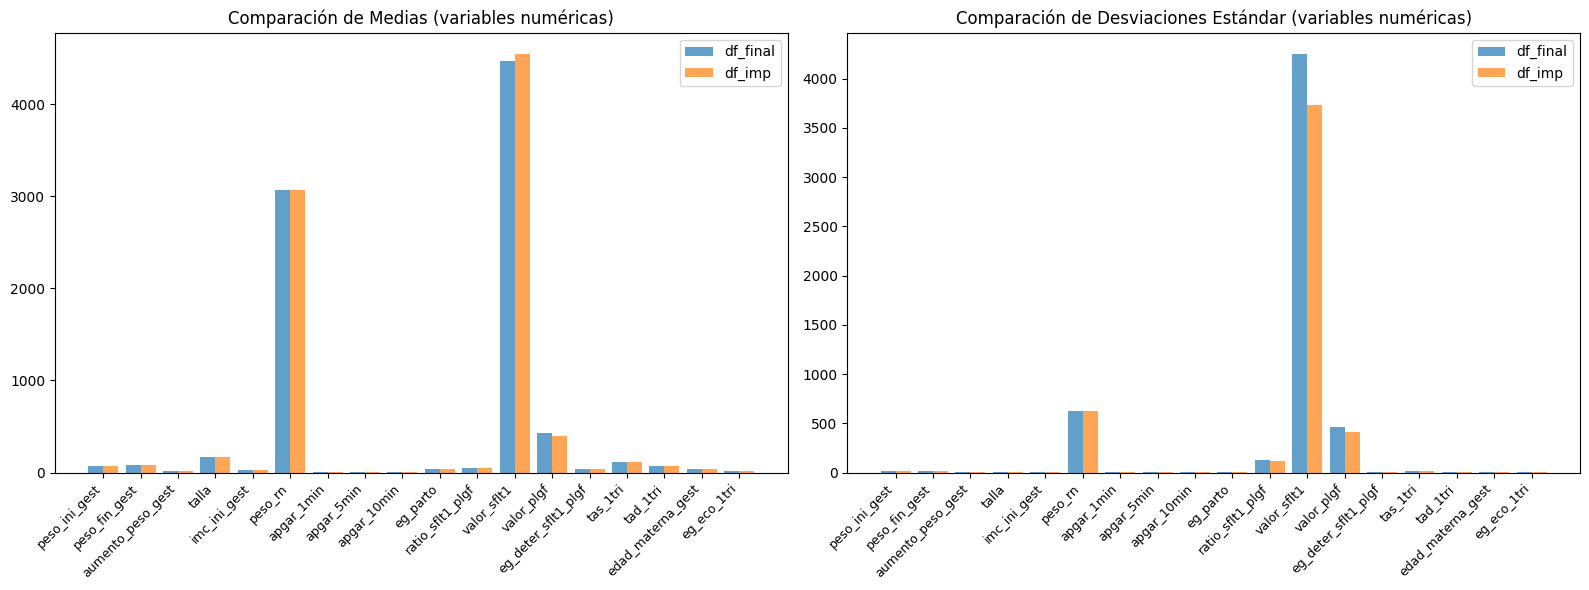

In [61]:
cols_numericas = [col for col in numericas if col in df_imp.columns]

mean_final = df_final[cols_numericas].mean()
std_final  = df_final[cols_numericas].std()

mean_imp = df_imp[cols_numericas].mean()
std_imp  = df_imp[cols_numericas].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = range(len(cols_numericas))

# Comparar medias
axes[0].bar([i - 0.2 for i in x], mean_final, width=0.4, label='df_final', alpha=0.7)
axes[0].bar([i + 0.2 for i in x], mean_imp,   width=0.4, label='df_imp',   alpha=0.7)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(cols_numericas, rotation=45, ha='right', fontsize=9)
axes[0].set_title('Comparación de Medias (variables numéricas)')
axes[0].legend()

# Comparar desviaciones estándar
axes[1].bar([i - 0.2 for i in x], std_final, width=0.4, label='df_final', alpha=0.7)
axes[1].bar([i + 0.2 for i in x], std_imp,   width=0.4, label='df_imp',   alpha=0.7)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(cols_numericas, rotation=45, ha='right', fontsize=9)
axes[1].set_title('Comparación de Desviaciones Estándar (variables numéricas)')
axes[1].legend()

plt.tight_layout()
plt.show()

# DUDAS:
- Cómo imputamos las fechas?
- Hay que añadir 'id' a df_imp